# Assignment 2.2 — streaming demo

For this demo I used the white wine csv from assignment 2.1 and trained models chunk by chunk (like data is still arriving) instead of loading everything at once.

I built two pipelines — one with a single decision tree, one with bagging — and used StreamTrainer to partial_fit each chunk and log accuracy. After training I also check streaming metrics (confusion matrix, precision, recall, f1) and plot accuracy over chunks.

## Setup

First cell adds NumCompute to the path so imports work when you open the notebook from demo/ (I kept getting ModuleNotFoundError without this). It also clears any cached numcompute_stream imports — if you still get ImportError after editing the package, restart the kernel and run from the top.

If you prefer you can pip install -e .. from the NumCompute folder instead and skip the path hack.

In [18]:
import sys
from pathlib import Path

import numpy as np

%matplotlib inline


def _find_package_root():
    # notebook is usually run from NumCompute/demo/
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent / "NumCompute",
    ]
    for path in candidates:
        if (path / "numcompute").is_dir() and (path / "numcompute_stream").is_dir():
            return path.resolve()
    raise ImportError(
        "Could not find numcompute. cd to NumCompute/demo or run: pip install -e .."
    )


root = _find_package_root()
root_str = str(root)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

# drop cached numcompute_stream modules so re-running setup picks up code changes
for mod_name in list(sys.modules):
    if mod_name == "numcompute_stream" or mod_name.startswith("numcompute_stream."):
        del sys.modules[mod_name]

from numcompute.io import load_csv
from numcompute_stream.ensemble import BaggingClassifier
from numcompute_stream.metrics import (
    StreamingConfusionMatrix,
    StreamingF1,
    StreamingPrecision,
    StreamingRecall,
)
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.preprocessing import StandardScaler
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.visualise import (
    compare_models,
    plot_metric_over_time,
    plot_predictions_vs_ground_truth,
)

np.set_printoptions(linewidth=120, precision=4, suppress=True)
print("using package root:", root)

using package root: /Users/megatunger/Github/numpy-compute/NumCompute


## 1. Load data

Same wine file as before — 11 input columns and quality in the last column.

I turned quality into a binary label: **1** if quality >= 6 (good enough), **0** otherwise, so the tree can do classification.

In [19]:
wine = load_csv("../assets/winequality-white.csv", dtype=np.float32, delimiter=";")
print("raw shape:", wine.shape)

X = wine[:, :11]
y = (wine[:, 11] >= 6).astype(int)

print("X shape:", X.shape)
print("class balance (0, 1):", np.bincount(y))

raw shape: (4898, 12)
X shape: (4898, 11)
class balance (0, 1): [1640 3258]


## 2. Split into chunks

I cut the dataset into batches of 50 rows. Each batch is one chunk that arrives later — that's what partial_fit is for in our streaming package.

In [20]:
chunk_size = 50
chunks = [
    (X[i:i + chunk_size], y[i:i + chunk_size])
    for i in range(0, len(X), chunk_size)
]

print(f"{len(chunks)} chunks of up to {chunk_size} rows")
print("first chunk shapes:", chunks[0][0].shape, chunks[0][1].shape)

98 chunks of up to 50 rows
first chunk shapes: (50, 11) (50,)


## 3. Build pipelines

Both pipelines scale features first (StandardScaler with partial_fit), then a model.

- pipe_tree — one decision tree, max_depth=5
- pipe_bagging — bagging with 5 trees (same depth), random_state=42 so runs are repeatable

In [21]:
pipe_tree = Pipeline([
    ("scale", StandardScaler()),
    ("model", DecisionTreeClassifier(max_depth=5, min_samples_split=2)),
])

pipe_bagging = Pipeline([
    ("scale", StandardScaler()),
    ("model", BaggingClassifier(n_estimators=5, max_depth=5, random_state=42)),
])

## 4. Train incrementally

Loop over every chunk and call fit_chunk on both trainers. That partial_fits the pipeline, predicts on the same chunk, and appends to log_ (chunk accuracy, cumulative accuracy, etc.).

I print tree vs bagging accuracy each chunk so you can see them improve as more data comes in.

In [22]:
trainer_tree = StreamTrainer(pipe_tree)
trainer_bagging = StreamTrainer(pipe_bagging)

tree_accuracies = []
bagging_accuracies = []

for i, (X_chunk, y_chunk) in enumerate(chunks):
    trainer_tree.fit_chunk(X_chunk, y_chunk)
    trainer_bagging.fit_chunk(X_chunk, y_chunk)

    tree_acc = trainer_tree.log_[-1]["chunk_accuracy"]
    bagging_acc = trainer_bagging.log_[-1]["chunk_accuracy"]
    tree_accuracies.append(tree_acc)
    bagging_accuracies.append(bagging_acc)

    print(
        f"chunk {i + 1:2d}/{len(chunks)} | "
        f"tree={tree_acc:.3f} | bagging={bagging_acc:.3f}"
    )

chunk  1/98 | tree=1.000 | bagging=0.960
chunk  2/98 | tree=0.980 | bagging=0.900
chunk  3/98 | tree=0.720 | bagging=0.760
chunk  4/98 | tree=0.580 | bagging=0.680
chunk  5/98 | tree=0.620 | bagging=0.660
chunk  6/98 | tree=0.740 | bagging=0.740
chunk  7/98 | tree=0.620 | bagging=0.740
chunk  8/98 | tree=0.840 | bagging=0.900
chunk  9/98 | tree=0.680 | bagging=0.780
chunk 10/98 | tree=0.720 | bagging=0.820
chunk 11/98 | tree=0.740 | bagging=0.760
chunk 12/98 | tree=0.740 | bagging=0.860
chunk 13/98 | tree=0.740 | bagging=0.560
chunk 14/98 | tree=0.620 | bagging=0.600
chunk 15/98 | tree=0.800 | bagging=0.700
chunk 16/98 | tree=0.900 | bagging=0.900
chunk 17/98 | tree=0.780 | bagging=0.640
chunk 18/98 | tree=0.700 | bagging=0.900
chunk 19/98 | tree=0.580 | bagging=0.600
chunk 20/98 | tree=0.720 | bagging=0.720
chunk 21/98 | tree=0.660 | bagging=0.800
chunk 22/98 | tree=0.640 | bagging=0.740
chunk 23/98 | tree=0.520 | bagging=0.660
chunk 24/98 | tree=0.720 | bagging=0.680
chunk 25/98 | tr

## 5. Streaming metrics

After all chunks are trained, I loop once more on the bagging model and feed every chunk into the streaming metric classes. They build up counts the same way as in the tests — two update calls on small arrays should match one batch call on the combined array.

In [23]:
cm = StreamingConfusionMatrix()
precision = StreamingPrecision(pos_label=1)
recall = StreamingRecall(pos_label=1)
f1 = StreamingF1(pos_label=1)

for X_chunk, y_chunk in chunks:
    y_pred = pipe_bagging.predict(X_chunk)
    cm.update(y_chunk, y_pred)
    precision.update(y_chunk, y_pred)
    recall.update(y_chunk, y_pred)
    f1.update(y_chunk, y_pred)

print("confusion matrix (bagging, all chunks):")
print(cm.result())
print("precision:", round(precision.result(), 3))
print("recall:", round(recall.result(), 3))
print("f1:", round(f1.result(), 3))

confusion matrix (bagging, all chunks):
[[ 465. 1175.]
 [ 249. 3009.]]
precision: 0.924
recall: 0.719
f1: 0.809


## 6. Plots

Using the visualise module I wrote for the assignment — line plot for the tree, side-by-side comparison with bagging, and a scatter of predictions vs labels on the last chunk (bagging model).

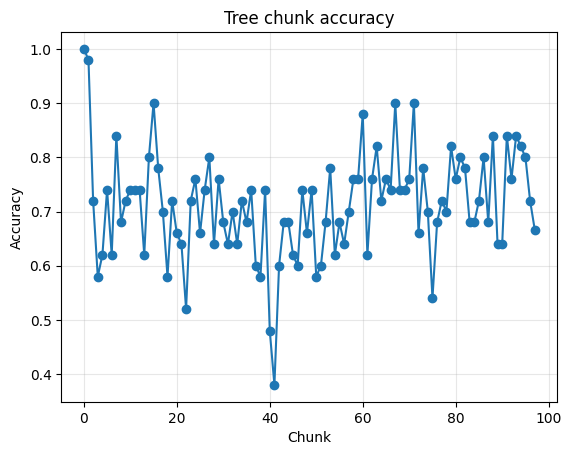

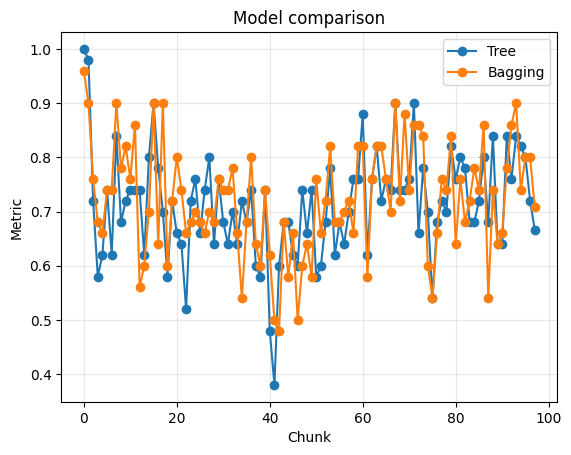

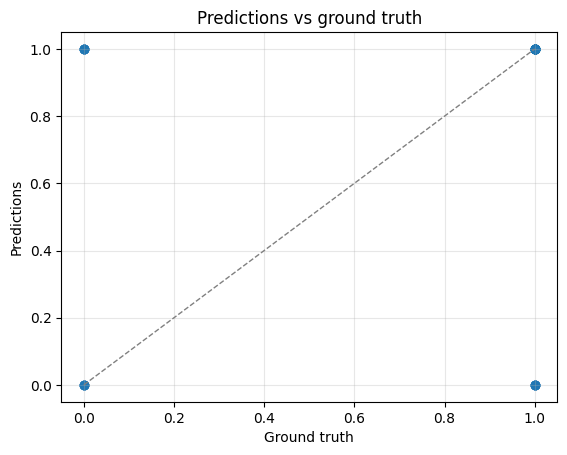

In [24]:
plot_metric_over_time(tree_accuracies, "Tree chunk accuracy", "Accuracy")
compare_models(tree_accuracies, bagging_accuracies, ["Tree", "Bagging"])

X_last, y_last = chunks[-1]
y_pred_last = pipe_bagging.predict(X_last)
plot_predictions_vs_ground_truth(y_last, y_pred_last)

## 7. Summary

Quick numbers at the end — how many chunks we trained on and final cumulative accuracy for both models.

In [25]:
print(f"chunks trained: {len(chunks)}")
print(f"tree cumulative accuracy: {trainer_tree.log_[-1]['cumulative_accuracy']:.3f}")
print(f"bagging cumulative accuracy: {trainer_bagging.log_[-1]['cumulative_accuracy']:.3f}")
print(f"tree scaler mean (first 3 features): {pipe_tree.named_steps['scale'].mean_[:3]}")

chunks trained: 98
tree cumulative accuracy: 0.713
bagging cumulative accuracy: 0.722
tree scaler mean (first 3 features): [6.8548 0.2782 0.3342]
